# Stage 1 — Building the recipe–ingredient graph

**Dataset:** RecipeNLG — `full_dataset.csv` (2.23M recipes, ~2.2 GB)

**What we build:**
- Bipartite graph `G`: recipes ↔ ingredients
- Ingredient–ingredient graph `I`: two ingredients are connected if they appear together in at least one recipe (edge weight = number of shared recipes)

**Key advantage of the dataset:** the `NER` column already contains normalized ingredient names — no NLP preprocessing required.

In [2]:
import ast
import time
import pickle
from collections import Counter
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

SEED = 42
DATA_PATH = Path('full_dataset.csv')
OUT_DIR   = Path('output_graphs')
OUT_DIR.mkdir(exist_ok=True)

print('Imports OK')
print(f'NetworkX: {nx.__version__}, pandas: {pd.__version__}')

Imports OK
NetworkX: 3.6.1, pandas: 2.3.1


## 1.1 Quick data inspection (first 5 rows)

In [3]:
sample = pd.read_csv(DATA_PATH, nrows=5)
print('Columns:', sample.columns.tolist())
print(f'\nExample row (index=0):')
for col in sample.columns:
    print(f'  {col:12s}: {sample.iloc[0][col]}')

Columns: ['Unnamed: 0', 'title', 'ingredients', 'directions', 'link', 'source', 'NER']

Example row (index=0):
  Unnamed: 0  : 0
  title       : No-Bake Nut Cookies
  ingredients : ["1 c. firmly packed brown sugar", "1/2 c. evaporated milk", "1/2 tsp. vanilla", "1/2 c. broken nuts (pecans)", "2 Tbsp. butter or margarine", "3 1/2 c. bite size shredded rice biscuits"]
  directions  : ["In a heavy 2-quart saucepan, mix brown sugar, nuts, evaporated milk and butter or margarine.", "Stir over medium heat until mixture bubbles all over top.", "Boil and stir 5 minutes more. Take off heat.", "Stir in vanilla and cereal; mix well.", "Using 2 teaspoons, drop and shape into 30 clusters on wax paper.", "Let stand until firm, about 30 minutes."]
  link        : www.cookbooks.com/Recipe-Details.aspx?id=44874
  source      : Gathered
  NER         : ["brown sugar", "milk", "vanilla", "nuts", "butter", "bite size shredded rice biscuits"]


In [4]:
df_sample = pd.read_csv(DATA_PATH, nrows=50_000, usecols=['title', 'NER'])
df_sample['ner_list'] = df_sample['NER'].apply(ast.literal_eval)

ing_lengths = df_sample['ner_list'].apply(len)
print(f'Recipes in sample     : {len(df_sample):,}')
print(f'Ingredients per recipe: mean={ing_lengths.mean():.1f}, '
      f'median={ing_lengths.median():.0f}, '
      f'max={ing_lengths.max()}')

all_ings = [i.lower().strip() for row in df_sample['ner_list'] for i in row]
top20 = Counter(all_ings).most_common(20)
print('\nTop-20 ingredients:')
for ing, cnt in top20:
    print(f'  {ing:<30} {cnt:>6,}')

Recipes in sample     : 50,000
Ingredients per recipe: mean=7.3, median=7, max=276

Top-20 ingredients:
  salt                           20,196
  sugar                          17,609
  flour                          12,835
  eggs                           11,624
  butter                         11,431
  onion                          10,173
  milk                            9,995
  vanilla                         7,484
  water                           7,204
  margarine                       5,032
  pepper                          4,479
  brown sugar                     4,094
  egg                             4,023
  baking powder                   3,912
  cream cheese                    3,592
  cinnamon                        3,510
  sour cream                      3,394
  nuts                            3,385
  celery                          3,295
  pineapple                       3,001


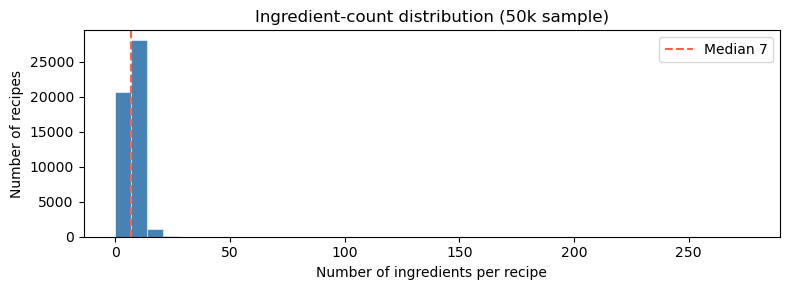

In [5]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(ing_lengths, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(ing_lengths.median(), color='tomato', linestyle='--', label=f'Median {ing_lengths.median():.0f}')
ax.set_xlabel('Number of ingredients per recipe')
ax.set_ylabel('Number of recipes')
ax.set_title('Ingredient-count distribution (50k sample)')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'ingredient_count_dist.png', dpi=120)
plt.show()

## 1.2 Loading the full dataset and counting co-occurrences

Building a full NetworkX graph over 2.23M recipes directly is memory-expensive (~8–10 GB).  
We therefore compute the **co-occurrence counts** with pandas first, then build the graph.

> Expected runtime: 3–6 minutes

In [6]:
CHUNK_SIZE = 100_000

cooc       = Counter()   # (ing_a, ing_b) -> count
ing_freq   = Counter()   # ing -> count across all recipes
total_rows = 0

t0 = time.time()
reader = pd.read_csv(DATA_PATH, usecols=['NER'], chunksize=CHUNK_SIZE)

for chunk in tqdm(reader, desc='Reading chunks', unit='chunk'):
    for raw_ner in chunk['NER']:
        try:
            ings = list({i.lower().strip() for i in ast.literal_eval(raw_ner) if i.strip()})
        except Exception:
            continue
        total_rows += 1
        ing_freq.update(ings)
        for a, b in combinations(sorted(ings), 2):
            cooc[(a, b)] += 1

elapsed = time.time() - t0
print(f'\nRecipes processed     : {total_rows:,}')
print(f'Unique ingredients    : {len(ing_freq):,}')
print(f'Ingredient pairs      : {len(cooc):,}')
print(f'Time                  : {elapsed:.0f} s')

Reading chunks: 0chunk [00:00, ?chunk/s]


Recipes processed     : 2,231,142
Unique ingredients    : 198,899
Ingredient pairs      : 5,981,626
Time                  : 139 s


In [7]:
with open(OUT_DIR / 'cooc.pkl', 'wb') as f:
    pickle.dump(cooc, f)
with open(OUT_DIR / 'ing_freq.pkl', 'wb') as f:
    pickle.dump(ing_freq, f)

print('Saved to output_graphs/')

Saved to output_graphs/


## 1.3 Building the ingredient–ingredient graph `I`

We filter out rare ingredients (< 50 recipes) and weak links (co-occurrence < 10) —  
this removes typos and noise, keeping only meaningful pairs.

Each edge stores **`weight`** — number of co-occurring recipes, and **`pmi`** — log PMI  
(reduces the bias of ubiquitous ingredients like salt compared to raw co-occurrence).

In [8]:
MIN_ING_FREQ = 50    # an ingredient must appear in at least 50 recipes
MIN_COOC     = 10    # a pair must co-occur in at least 10 recipes

valid_ings = {ing for ing, cnt in ing_freq.items() if cnt >= MIN_ING_FREQ}
print(f'Ingredients with freq >= {MIN_ING_FREQ}: {len(valid_ings):,}')

# PMI (Pointwise Mutual Information) penalises trivial pairs (salt + anything)
# and rewards specific ones; stored alongside the frequency `weight`
total_pairs = sum(cooc.values())
total_ings  = float(sum(ing_freq.values()))

I = nx.Graph()
I.add_nodes_from(valid_ings)

for (a, b), w in tqdm(cooc.items(), desc='Building graph I'):
    if a in valid_ings and b in valid_ings and w >= MIN_COOC:
        pa  = ing_freq[a] / total_ings
        pb  = ing_freq[b] / total_ings
        pab = w / total_pairs
        pmi = float(np.log(pab / (pa * pb + 1e-9)))
        I.add_edge(a, b, weight=w, log_weight=np.log1p(w), pmi=pmi)

nx.set_node_attributes(I, dict(ing_freq), name='freq')

print(f'\nGraph I (ingredient-ingredient):')
print(f'  Nodes    : {I.number_of_nodes():,}')
print(f'  Edges    : {I.number_of_edges():,}')
print(f'  Density  : {nx.density(I):.6f}')

lcc = max(nx.connected_components(I), key=len)
print(f'  LCC size : {len(lcc):,} ({100*len(lcc)/I.number_of_nodes():.1f}% of nodes)')

Ingredients with freq >= 50: 7,199


Building graph I:   0%|          | 0/5981626 [00:00<?, ?it/s]


Graph I (ingredient-ingredient):
  Nodes    : 7,199
  Edges    : 418,645
  Density  : 0.016158
  LCC size : 7,196 (100.0% of nodes)


## 1.4 Building the bipartite graph `G` (on a sample)

The full bipartite graph (2.23M recipes) requires ~8–10 GB RAM.  
We build it on **200k recipes** to analyze structure and visualize.

In [9]:
BIPARTITE_SAMPLE = 200_000

df_bip = pd.read_csv(DATA_PATH, nrows=BIPARTITE_SAMPLE, usecols=['title', 'NER'])
df_bip['ner_list'] = df_bip['NER'].apply(ast.literal_eval)

G = nx.Graph()

for idx, row in tqdm(df_bip.iterrows(), total=len(df_bip), desc='Building graph G'):
    r_id = f'recipe::{idx}'
    G.add_node(r_id, ntype='recipe', title=row['title'])
    for ing in row['ner_list']:
        name = ing.lower().strip()
        if not name:
            continue
        G.add_node(name, ntype='ingredient', freq=ing_freq.get(name, 0))
        G.add_edge(r_id, name)

recipe_nodes = {n for n,d in G.nodes(data=True) if d.get('ntype')=='recipe'}
ing_nodes    = {n for n,d in G.nodes(data=True) if d.get('ntype')=='ingredient'}

print(f'\nBipartite graph G ({BIPARTITE_SAMPLE:,} recipes):')
print(f'  Recipes      : {len(recipe_nodes):,}')
print(f'  Ingredients  : {len(ing_nodes):,}')
print(f'  Edges        : {G.number_of_edges():,}')
print(f'  Bipartite?   : {nx.is_bipartite(G)}')

Building graph G:   0%|          | 0/200000 [00:00<?, ?it/s]


Bipartite graph G (200,000 recipes):
  Recipes      : 200,000
  Ingredients  : 22,534
  Edges        : 1,449,174
  Bipartite?   : True


## 1.5 Statistics of graph I

In [10]:
degrees  = dict(I.degree())
deg_vals = list(degrees.values())

print('=== Graph I (ingredient-ingredient) ===')
print(f'Mean degree      : {np.mean(deg_vals):.1f}')
print(f'Median degree    : {np.median(deg_vals):.0f}')
print(f'Max degree       : {max(deg_vals)}')
print(f'Ingredient (max) : {max(degrees, key=degrees.get)}')

print('\nTop-15 ingredients by degree:')
for ing, deg in sorted(degrees.items(), key=lambda x: -x[1])[:15]:
    freq = ing_freq.get(ing, 0)
    print(f'  {ing:<30} degree={deg:>5,}  freq={freq:>7,}')

print('\nTop-10 pairs by weight (co-occurrence):')
sorted_edges = sorted(I.edges(data=True), key=lambda e: -e[2]['weight'])
for a, b, d in sorted_edges[:10]:
    print(f'  {a:<25} + {b:<25}  w={d["weight"]:,}')

=== Graph I (ingredient-ingredient) ===
Mean degree      : 116.3
Median degree    : 27
Max degree       : 6743
Ingredient (max) : salt

Top-15 ingredients by degree:
  salt                           degree=6,743  freq=959,350
  water                          degree=5,693  freq=334,886
  butter                         degree=5,525  freq=502,604
  sugar                          degree=5,345  freq=602,734
  garlic                         degree=5,205  freq=370,008
  onion                          degree=4,865  freq=386,037
  flour                          degree=4,766  freq=468,993
  eggs                           degree=4,664  freq=418,586
  milk                           degree=4,533  freq=357,388
  olive oil                      degree=4,312  freq=214,856
  lemon juice                    degree=3,812  freq=152,447
  tomatoes                       degree=3,788  freq=169,423
  pepper                         degree=3,590  freq=188,745
  egg                            degree=3,410  freq=17

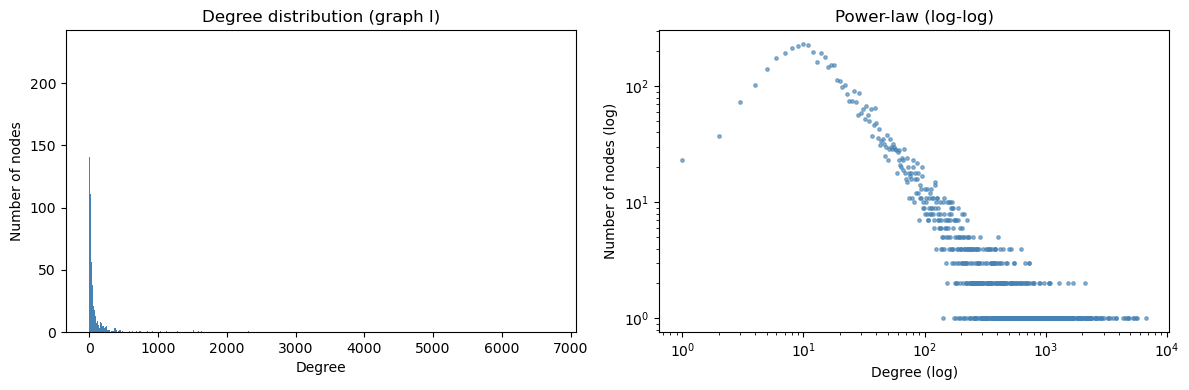

In [11]:
from collections import Counter as Cnt
deg_dist = Cnt(deg_vals)
xs = sorted(deg_dist.keys())
ys = [deg_dist[x] for x in xs]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(xs, ys, color='steelblue', width=1)
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Number of nodes')
axes[0].set_title('Degree distribution (graph I)')

axes[1].scatter(xs, ys, s=6, alpha=0.6, color='steelblue')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel('Degree (log)')
axes[1].set_ylabel('Number of nodes (log)')
axes[1].set_title('Power-law (log-log)')

plt.tight_layout()
plt.savefig(OUT_DIR / 'degree_distribution.png', dpi=120)
plt.show()

## 1.6 Subgraph visualization

We take the **ego-graph** of a popular ingredient — all its neighbors and the edges among them.

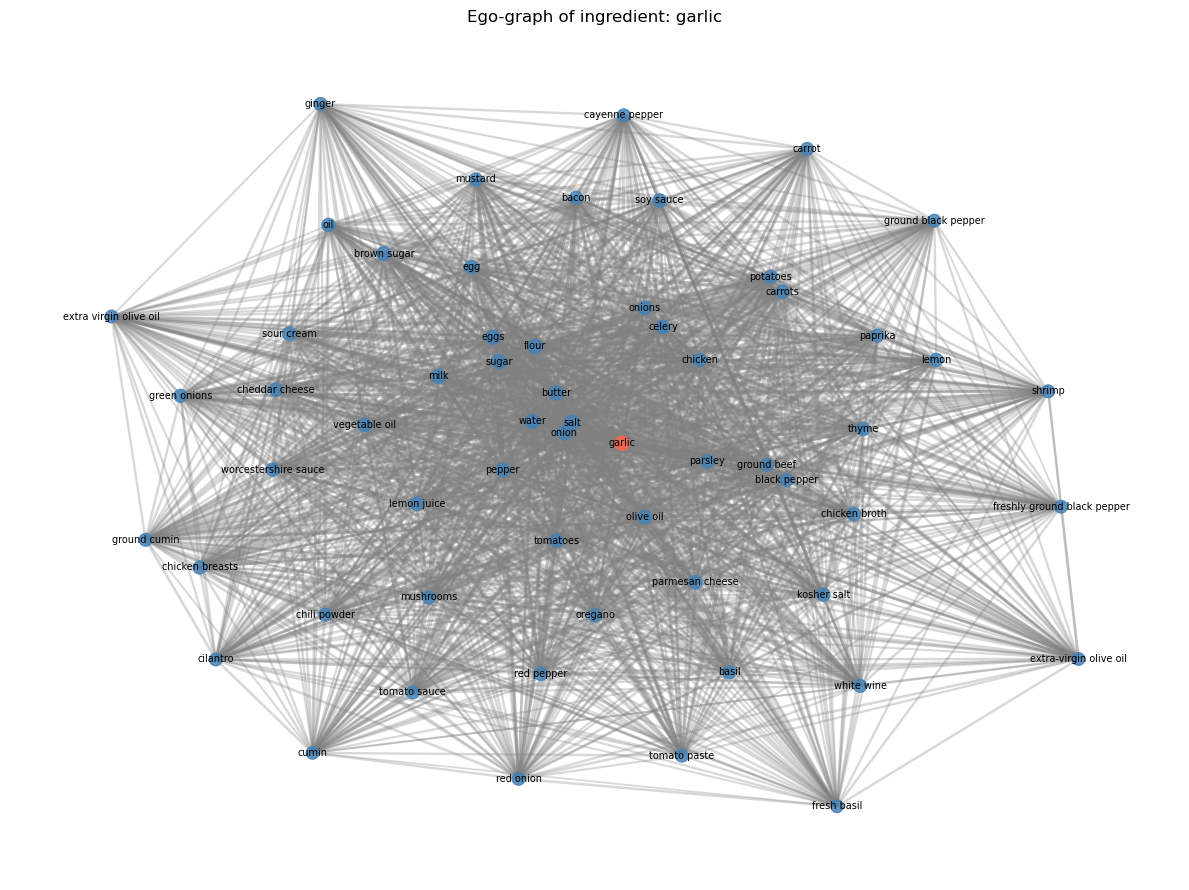

In [12]:
def plot_ego(G_full, center_node, radius=1, max_nodes=80, title=None):
    ego = nx.ego_graph(G_full, center_node, radius=radius, undirected=True)
    if len(ego) > max_nodes:
        top_neighbors = sorted(
            ego.neighbors(center_node),
            key=lambda n: ego[center_node][n].get('weight', 1),
            reverse=True
        )[:max_nodes - 1]
        ego = ego.subgraph([center_node] + top_neighbors).copy()

    pos = nx.spring_layout(ego, seed=SEED, k=0.8)
    
    freqs = [ego.nodes[n].get('freq', ing_freq.get(n, 1)) for n in ego.nodes]
    sizes = [max(40, 8 * np.log1p(f)) for f in freqs]
    colors = ['tomato' if n == center_node else 'steelblue' for n in ego.nodes]

    weights = [ego[u][v].get('log_weight', 1) for u, v in ego.edges]
    max_w   = max(weights) if weights else 1
    widths  = [0.3 + 2.5 * w / max_w for w in weights]

    fig, ax = plt.subplots(figsize=(12, 9))
    nx.draw_networkx_nodes(ego, pos, node_size=sizes, node_color=colors, alpha=0.85, ax=ax)
    nx.draw_networkx_edges(ego, pos, width=widths, alpha=0.3, edge_color='grey', ax=ax)
    nx.draw_networkx_labels(ego, pos, font_size=7, ax=ax)
    ax.set_title(title or f'Ego-graph: {center_node} (radius={radius})')
    ax.axis('off')
    plt.tight_layout()
    return fig

# Ego-graph around 'garlic'
fig = plot_ego(I, 'garlic', radius=1, max_nodes=60, title='Ego-graph of ingredient: garlic')
fig.savefig(OUT_DIR / 'ego_garlic.png', dpi=120)
plt.show()

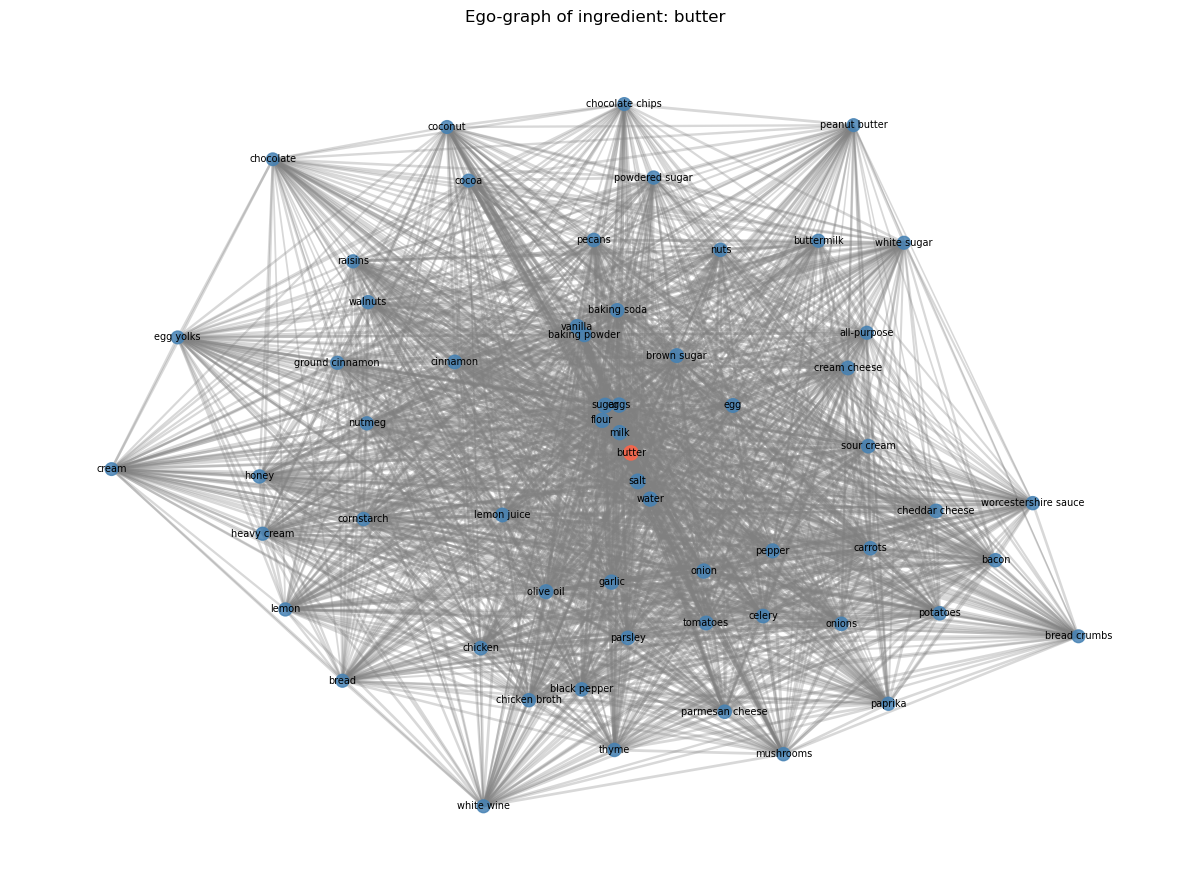

In [13]:
# Ego-graph around 'butter'
fig = plot_ego(I, 'butter', radius=1, max_nodes=60, title='Ego-graph of ingredient: butter')
fig.savefig(OUT_DIR / 'ego_butter.png', dpi=120)
plt.show()

## 1.7 Saving graphs

In [14]:
nx.write_graphml(I, OUT_DIR / 'ingredient_graph.graphml')

nx.write_graphml(G, OUT_DIR / 'bipartite_sample.graphml')

ing_freq_df = pd.DataFrame(
    [(ing, cnt) for ing, cnt in ing_freq.items()],
    columns=['ingredient', 'freq']
).sort_values('freq', ascending=False)
ing_freq_df.to_csv(OUT_DIR / 'ingredient_freq.csv', index=False)

print('Saved:')
for f in sorted(OUT_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f'  {f.name:<35} {size_mb:.1f} MB')

Saved:
  bipartite_sample.graphml            107.6 MB
  chem_embs.pkl                       9.7 MB
  cooc.pkl                            130.7 MB
  cuisine_clusters_umap.png           0.9 MB
  degree_distribution.png             0.1 MB
  ego_butter.png                      0.9 MB
  ego_garlic.png                      1.0 MB
  feature_correlation.png             0.1 MB
  flavordb_cache.json                 1.4 MB
  food_pairing_boxplots.png           0.0 MB
  food_pairing_global.png             0.1 MB
  food_pairing_results.csv            0.0 MB
  food_pairing_summary.json           0.0 MB
  gae_loss_curve.png                  0.0 MB
  gae_model.pt                        0.6 MB
  graphsage_model.pt                  0.2 MB
  ing_freq.pkl                        4.4 MB
  ingredient_count_dist.png           0.0 MB
  ingredient_embeddings.npz           1.8 MB
  ingredient_freq.csv                 4.0 MB
  ingredient_graph.graphml            79.8 MB
  link_prediction_results.png         0.0 M

## 1.8 Stage 1 summary

| Artifact | File | Description |
|---|---|---|
| Graph I | `ingredient_graph.graphml` | Main — used in Link Prediction and Substitution |
| Graph G (sample) | `bipartite_sample.graphml` | For GNN (stage 3) and visualization |
| Frequencies | `ingredient_freq.csv` | Required for Feature Engineering (stage 2) |
| Co-occurrence | `cooc.pkl` | Raw pairs — for extra metrics |

**Next step → Stage 2: Feature Engineering**  
For each ingredient node we add structural features (degree, PageRank) and chemical embeddings from FlavorDB.